# Ćw.5. Zastosowanie PyTorch do wizji komputerowej (Computer Vision).

[Computer vision](https://en.wikipedia.org/wiki/Computer_vision) to sztuka uczenia komputera, by rozpoznawał obraz.

Może to polegać na zbudowaniu modelu klasyfikującego, czy zdjęcie przedstawia kota czy psa ([binary classification](https://developers.google.com/machine-learning/glossary#binary-classification)).

Zadanie, by przewidzieć, czy zdjęcie przedstawia kota, psa czy kurczaka, to klasyfikacja wieloklasowa ([multi-class classification](https://developers.google.com/machine-learning/glossary#multi-class-classification)).

Lub identyfikacja miejsca, w którym samochód pojawia się na klatce wideo ([object detection](https://en.wikipedia.org/wiki/Object_detection)).

Lub ustalenie, gdzie można oddzielić różne obiekty na obrazie ([panoptic segmentation](https://arxiv.org/abs/1801.00868)).
Są to przykładowe problemy wizji komputerowej dla klasyfikacji binarnej, klasyfikacji wieloklasowej, wykrywania obiektów i segmentacji.

## Gdzie stosowana jest wizja komputerowa?

Jeśli korzystasz ze smartfona, masz już do czynienia z wizją komputerową.

Aparat i aplikacje fotograficzne używają [wizji komputerowej](https://machinelearning.apple.com/research/panoptic-segmentation) do rozpoznawania i porządkowania zdjęć.

Nowoczesne samochody wykorzystują [wizję komputerową](https://youtu.be/j0z4FweCy4M?t=2989) do wielu celów, parkowanie, hamowanie przed przeszkodą itd.

Producenci wykorzystują wizję komputerową do identyfikowania wad różnych produktów.

Kamery bezpieczeństwa wykorzystują wizję komputerową do wykrywania potencjalnych intruzów.

Zasadniczo wszystko, co można opisać za pomocą zmysłu wzroku, może stanowić potencjalny problem związany z wizją komputerową.
Zobacz czym różni się wizja komputerowa od rozpoznawania obrazów: [Rozpoznawanie obrazów vs. wizja komputerowa](https://www.unite.ai/pl/image-recognition-vs-computer-vision/).

## Zawartość ćwiczeń


W szczególności zajmiemy się:

| **Temat** | **Zawartość** |
| ----- | ----- |
| **0. Biblioteki wizji komputerowej w PyTorch** | Przegląd wbudowanych pomocnych bibliotek wizji komputerowej w PyTorch.  |
| **1. Załaduj dane** | Obrazy różnych ubrań z [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). |
| **2. Przygotuj dane** | Ładowanie obrazów za pomocą [PyTorch `DataLoader`](https://pytorch.org/docs/stable/data.html), w celu użycia ich w pętli treningowej. |
| **3. Model 0: Budowanie modelu bazowego** | Budowa wieloklasowego modelu klasyfikacyjnego, aby nauczyć się wzorców w danych. Wybór **funkcji straty**, **optymalizatora** i budowa **pętli uczącej**. |
| **4. Wykonywanie prognoz i ocena modelu 0** | Wykonanie prognoz z  modelem bazowym i ich ocena. |
| **5. Konfiguracja kodu niezależnego od urządzenia dla przyszłych modeli** | Najlepszą praktyką jest pisanie kodu niezależnego od urządzenia, więc skonfigurujmy go. |
| **6. Model 1: Dodanie nieliniowości** | Eksperymentowanie jest dużą częścią uczenia maszynowego, ulepszamy  model bazowy, dodając warstwy nieliniowe. |
| **7. Model 2: Konwolucyjna sieć neuronowa (CNN)** | Wprowadzenie  architektury konwolucyjnej sieci neuronowej. |
| **8. Porównanie naszych modeli** | Zbudowaliśmy trzy różne modele, porównajmy je. |
| **9. Ocena naszego najlepszego modelu** | Zróbmy kilka prognoz na losowych obrazach i oceńmy nasz najlepszy model. |
| **10. Tworzenie macierzy pomyłek** | Tworzenie macierzy pomyłek. |
| **11. Zapisywanie i ładowanie najlepiej działającego modelu** | Ponieważ możemy chcieć użyć naszego modelu później, zapiszmy go i upewnijmy się, że ładuje się poprawnie. |

## 0. Biblioteki PyTorch do wizji komputerowej.

Przegląd bibliotek PyTorch do wizji komputerowej.
| Moduł PyTorch | Do czego służy? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Zawiera zbiory danych, architektury modeli i transformacje obrazów często używane w komputerowych systemach wizyjnych. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Zawiera przykładowe zestawy danych do wizji komputerowej dla szeregu problemów, od klasyfikacji obrazów, wykrywania obiektów, podpisywania obrazów, klasyfikacji wideo i innych. Zawiera również [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | Moduł ten zawiera dobrze działające i powszechnie używane architektury modeli wizji komputerowej zaimplementowane w PyTorch, które można wykorzystać do rozwiązywania własnych problemów. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Często obrazy muszą zostać przekształcone (zamienione na liczby/przetworzone/powiększone/rotowane) przed użyciem w modelu, typowe przekształcenia obrazów można znaleźć tutaj. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Podstawowa klasa zbioru danych dla PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Tworzy iterowalną tabelę Pythona na zbiorze danych (utworzonym za pomocą funkcji `torch.utils.data.Dataset`). |

> **Uwaga:** Klasy `torch.utils.data.Dataset` i `torch.utils.data.DataLoader` nie są przeznaczone tylko do wizji komputerowej w PyTorch, są one w stanie poradzić sobie z wieloma różnymi typami danych.

Teraz omówiliśmy niektóre z najważniejszych bibliotek wizji komputerowej PyTorch, zaimportujmy odpowiednie zależności.

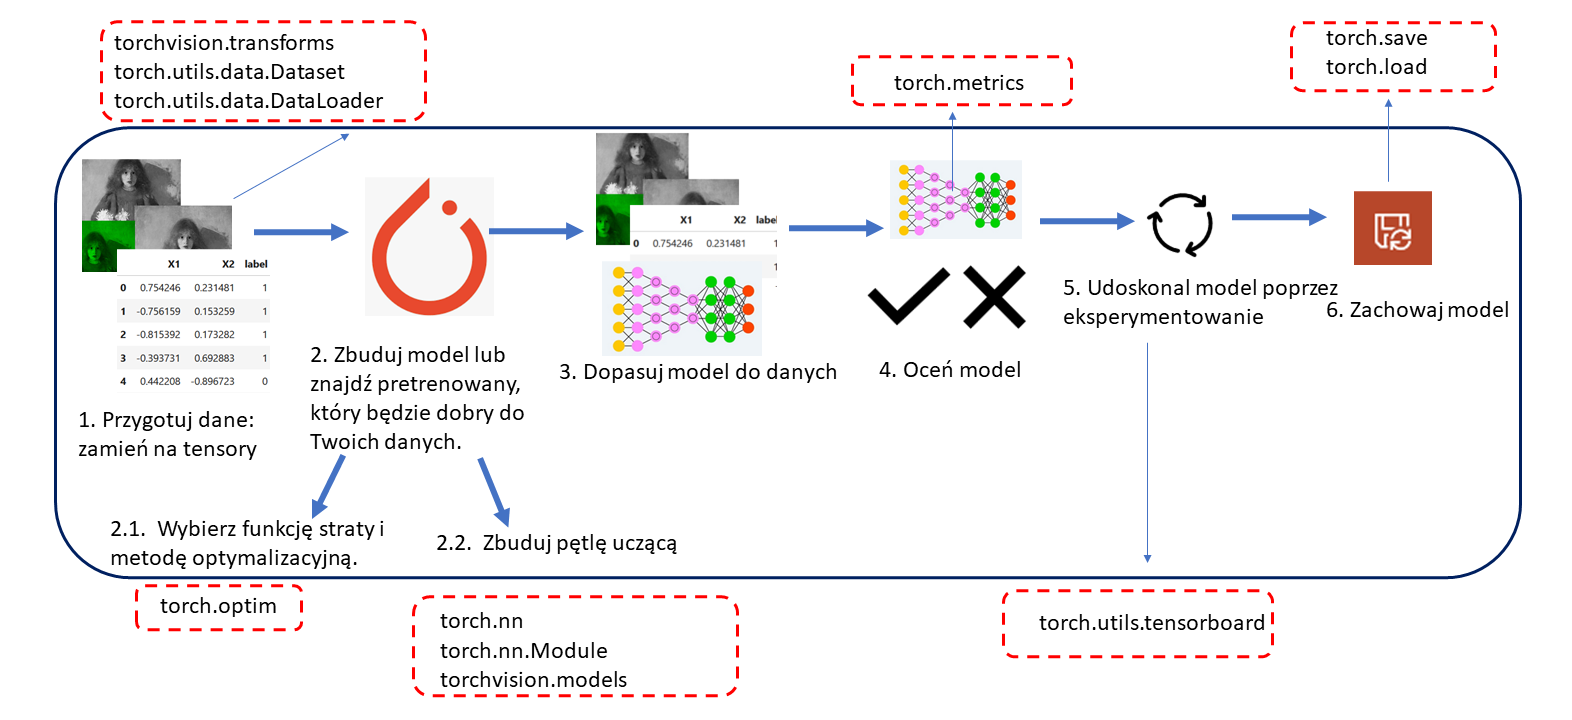

In [ ]:
from IPython.display import Image
Image('/content/Cw5Obraz1.png')

In [ ]:
# Importowanie PyTorch
import torch
from torch import nn

# Importowanie torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Importowanie matplotlib na potrzeby wizualizacji
import matplotlib.pyplot as plt

# Sprawdź wersje
# Uwaga: wersja PyTorch nie powinna być niższa niż 1.10.0, a wersja torchvision nie powinna być niższa niż 0.11.
print(f" wersja PyTorch: {torch.__version__}\nwersja torchvision: {torchvision.__version__}")

 wersja PyTorch: 2.10.0+cu128
wersja torchvision: 0.25.0+cu128


## 1. Załadowanie zbioru danych

Załadujemy zbiór do wizji komputerowej:  FashionMNIST.

MNIST oznacza Zmodyfikowany Narodowy Instytut Standardów i Technologii.

 [Oryginalny zbiór MNIST](https://en.wikipedia.org/wiki/MNIST_database) zawiera tysiące przykładów odręcznie napisanych cyfr (od 0 do 9) i został wykorzystany do zbudowania komputerowych modeli wizyjnych do identyfikacji numerów dla usług pocztowych.

[FashionMNIST](https://github.com/zalandoresearch/fashion-mnist),  utworzony przez Zalando Research zawiera zdjęcia 10 różnych rodzajów ubrań w odcieniach szarości.

*`torchvision.datasets`* zawiera wiele przykładowych zestawów danych, które można wykorzystać do ćwiczenia pisania kodu wizji komputerowej. FashionMNIST jest jednym z nich. Ponieważ zawiera  10 różnych klas obrazów (różne rodzaje odzieży), jest to problem klasyfikacji wieloklasowej.

PyTorch ma kilka popularnych zestawów danych wizji komputerowej przechowywanych w `torchvision.datasets`, także

FashionMNIST w [`torchvision.datasets.FashionMNIST()`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html).

Aby go pobrać, podajemy następujące parametry:
* `root: str` - do którego folderu mają zostać pobrane dane?
* `train: Bool` - czy chcesz mieć podział treningowy czy testowy?
* `download: Bool` - czy dane mają zostać pobrane?
* `transform: torchvision.transforms` - jakie transformacje chcesz wykonać na danych?
* `target_transform` - możesz przekształcić cele (etykiety), jeśli chcesz.

Wiele innych zestawów danych w `torchvision` posiada te opcje parametrów.

In [ ]:
# Konfiguracja danych uczących
train_data = datasets.FashionMNIST(
    root="data", # gdzie/dokąd pobrać dane?
    train=True, # pobranie danych
    download=True, # załadować dane, jeśli nie istnieją na dysku
    transform=ToTensor(), # obrazy są dostarczane w formacie PIL, który chcemy przekształcić w tensory Torch
    target_transform=None # można również przekształcać etykiety
)

# Konfiguracja danych testowych
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # pobranie danych testowych
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]


Sprawdźmy pierwszą próbkę danych treningowych.

In [ ]:
# Pierwsza próbka danych treningowych.
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### 1.1 Kształty wejścia i wyjścia modelu wizji komputerowej

Mamy duży tensor wartości (obraz) prowadzący do pojedynczej wartości dla celu (etykieta).

Zobaczmy kształt obrazu.

In [ ]:
# Sprawdzenie kształtu obrazu
image.shape

torch.Size([1, 28, 28])

Kształt tensora obrazu to `[1, 28, 28]` lub bardziej szczegółowo:

```
[color_channels=1, height=28, width=28]
```

`color_channels=1` oznacza, że obraz jest w skali szarości.

In [ ]:
from IPython.display import Image
Image('/content/Cw5Obraz2.png')

FileNotFoundError: No such file or directory: '/content/Cw5Obraz2.png'

FileNotFoundError: No such file or directory: '/content/Cw5Obraz2.png'

<IPython.core.display.Image object>

*Różne problemy będą miały różne kształty danych wejściowych i wyjściowych. Ale założenie pozostaje: zakoduj dane w liczbach, zbuduj model, aby znaleźć wzorce w tych liczbach, przekształć te wzorce w coś znaczącego*.

Jeśli `color_channels=3`, obraz jest dostarczany w wartościach pikseli dla koloru czerwonego, zielonego i niebieskiego (jest to również znane jako [RGB color model](https://en.wikipedia.org/wiki/RGB_color_model)).

Kolejność naszego obecnego tensora jest często określana jako `CHW` (kanały kolorów, wysokość, szerokość).

Toczy się debata na temat tego, czy obrazy powinny być reprezentowane jako `CHW` (kanały kolorów jako pierwsze) czy `HWC` (kanały kolorów jako ostatnie).
> **UWAGA:** Zobaczysz również formaty `NCHW` i `NHWC`, gdzie `N` oznacza *liczbę obrazów*. Na przykład, jeśli masz `batch_size=32`, twój kształt tensora może być `[32, 1, 28, 28]`. Rozmiary paczki danych (batch size)  później.

PyTorch generalnie akceptuje `NCHW` (najpierw kanały) jako domyślne dla wielu operatorów.

Jednak PyTorch wyjaśnia również, że `NHWC` (ostatnie kanały) działa lepiej i jest [uważany za dobrą praktykę](https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice).

Na razie, ponieważ nasz zbiór danych i modele są stosunkowo małe, nie będzie to miało zbyt dużego znaczenia.

Należy jednak o tym pamiętać podczas pracy z większymi zbiorami danych obrazów i przy użyciu konwolucyjnych sieci neuronowych (zobaczymy je później).

Sprawdźmy więcej kształtów naszych danych.

In [ ]:
# Ile mamy próbek?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

Mamy więc 60 000 próbek treningowych i 10 000 próbek testowych.

Jakie mamy klasy?

Możemy je znaleźć za pomocą atrybutu .classes.

In [ ]:
# Podgląd klas
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Super! Wygląda na to, że mamy do czynienia z 10 różnymi rodzajami ubrań.

Ponieważ pracujemy z 10 różnymi klasami, oznacza to, że nasz problemem jest problemem **klasyfikacji wieloklasowej**.

Zróbmy wizualizację.

### 1.2 Wizualizacja danych

Image shape: torch.Size([1, 28, 28])


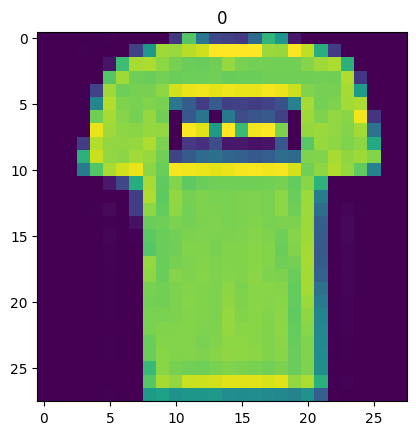

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[1]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # kształt obrazu to [1, 28, 28] (kanały kolorów, wysokość, szerokość)
plt.title(label);

Możemy zamienić obraz na skalę szarości używając parametru `cmap` w `plt.imshow()`.

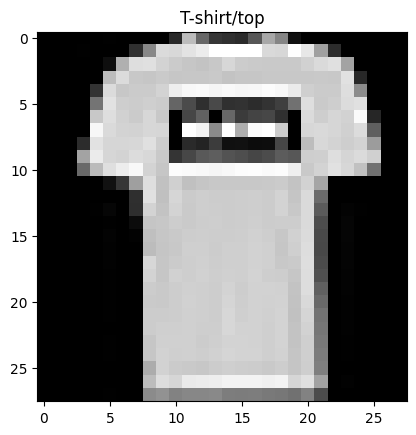

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

Super!

Zobaczmy jeszcze kilka.

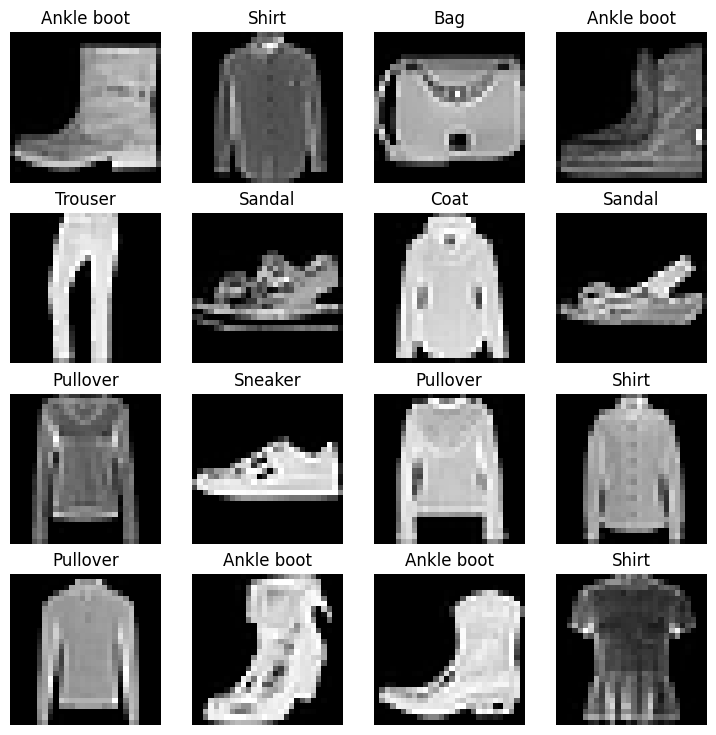

In [ ]:
# więcej zdjęć
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

Ten rozpikselowany zbiór danych nie wygląda zbyt estetycznie.

Ale zasady, których się nauczymy, jak zbudować dla niego model, będą podobne w szerokim zakresie problemów związanych z wizją komputerową.

Zasadniczo, to pobieranie wartości pikseli i budowanie modelu w celu znalezienia w nich wzorców do wykorzystania w przyszłych wartościach pikseli.

Ponadto, nawet dla tego małego zbioru danych (tak, nawet 60 000 obrazów w głębokim uczeniu jest uważane za dość małe), możemy napisać program klasyfikujący każdy z nich.


**Pytanie:** Czy uważasz, że powyższe dane można modelować tylko za pomocą linii prostych (liniowych)? A może potrzebne są również nieliniowości?

## 2. Przygotowanie DataLoader

Mamy już zbiór danych. Kolejnym krokiem jest przygotowanie go z

[`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) lub krótko `DataLoaderem`.

 `DataLoader`  pomaga załadować dane do modelu. Do uczenia i wnioskowania.

Zamienia duży `Dataset` w mniejsze fragmenty do obróbki przez PyTorch.

Te mniejsze fragmenty to paczki danych **batches** lub **mini-batches**, które mogą być określone  przez parametr`batch_size`.
Po co to robimy?

Ponieważ jest to bardziej wydajne obliczeniowo.

W idealnym świecie można by wykonywać operacje „forward pass” i „backward pass” na wszystkich danych jednocześnie.

Ale gdy zaczniesz używać naprawdę dużych zbiorów danych, o ile nie masz nieskończonej mocy obliczeniowej, łatwiej jest podzielić je na partie.

Daje to również modelowi więcej możliwości poprawy.

W przypadku **mini-batch** (małych paczek danych), spadek gradientowy jest wykonywany częściej na epokę (raz na mini-batch, a nie raz na epokę).

Jaki jest dobry rozmiar tej paczki danych? 32 jest dobrą wartoscią na początek dla sporej liczby zadań.

Ale ponieważ jest to wartość, którą można ustawić (**hiperparametr**), można wypróbować różne rodzaje wartości, choć generalnie najczęściej używane są potęgi 2 (np. 32, 64, 128, 256, 512).

Utworzymy paczki dla FashionMNIST z rozmiarem  32 i włączonym shuffle. Podobny proces będzie miał miejsce dla innych zbiorów danych, ale będzie się różnił w zależności od wielkości paczki batch.

Utwórzmy `DataLoader` dla naszych zestawów treningowych i testowych.

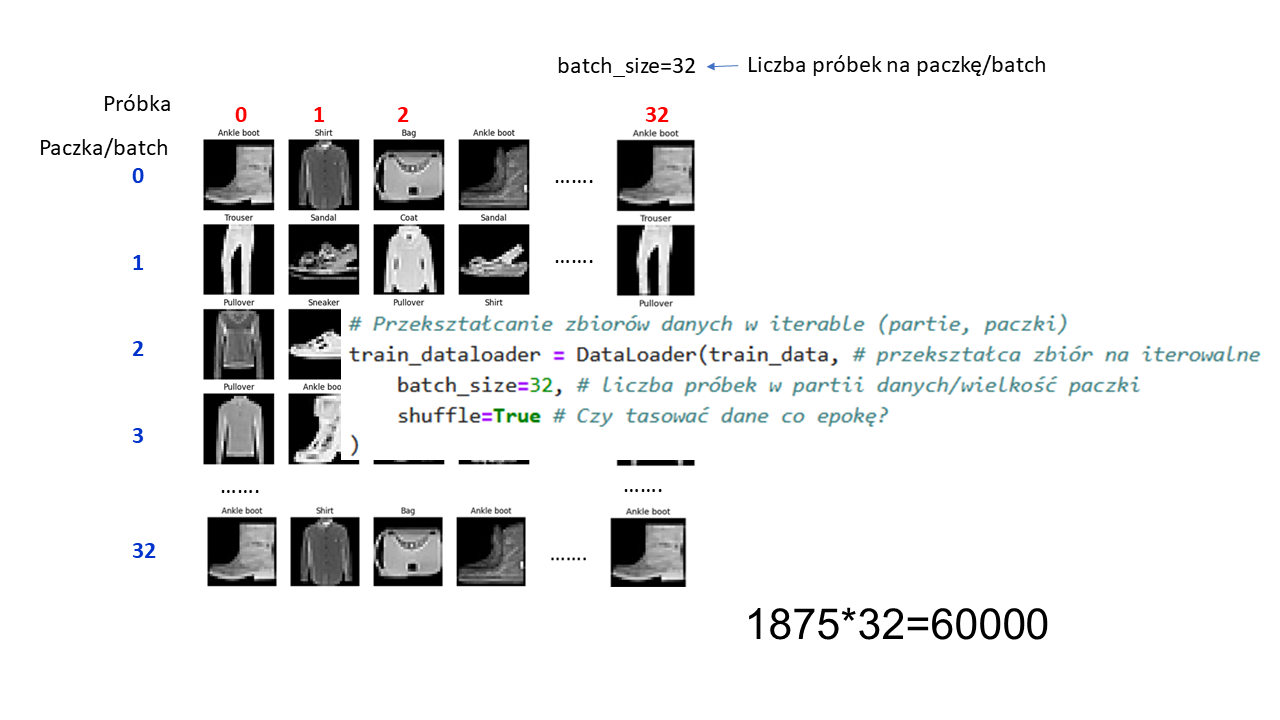

In [ ]:
from IPython.display import Image
Image('/content/Cw5Obraz3.png')

In [ ]:
from torch.utils.data import DataLoader

# Konfiguracja hiperparametru wielkości paczki (batch)
BATCH_SIZE = 32

# Przekształcanie zbiorów danych w iterable (partie, paczki)
train_dataloader = DataLoader(train_data, # przekształca zbiór na iterowalne, (an iterable is any Python object capable of returning its members one at a time, permitting it to be iterated over in a for-loop. Familiar examples of iterables include lists, tuples, and strings - any such sequence can be iterated over in a for-loop.
    batch_size=BATCH_SIZE, # liczba próbek w partii danych/wielkość paczki
    shuffle=True # Czy tasować dane co epokę?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # nie jest konieczne tasowanie danych testowych
)

# Zobaczmy, co zbudowaliśmy
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Długość uczącego dataloader: {len(train_dataloader)} paczek o {BATCH_SIZE} elementach")
print(f"Długość testowego dataloader: {len(test_dataloader)} paczek/batches o {BATCH_SIZE} próbkach")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a488996fa10>, <torch.utils.data.dataloader.DataLoader object at 0x7a48895eeb10>)
Długość uczącego dataloader: 1875 paczek o 32 elementach
Długość testowego dataloader: 313 paczek/batches o 32 próbkach


In [ ]:
# Sprawdź, co zawiera treningowy DataLoader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Widzimy, że dane pozostają niezmienione.

Rozmiar obrazu: torch.Size([1, 28, 28])
Etykieta: 6, label size: torch.Size([])


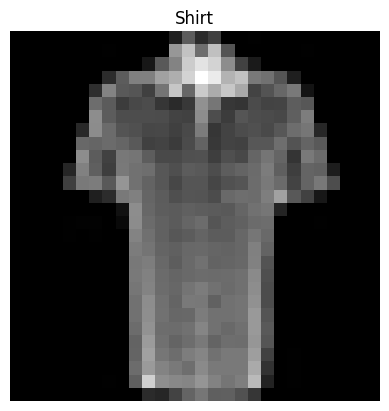

In [ ]:
# Podglad próbki
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Rozmiar obrazu: {img.shape}")
print(f"Etykieta: {label}, label size: {label.shape}")

## 3. Model 0: Zbuduj model bazowy

Dane załadowane i przygotowane!

Zbudujemy **model bazowy** poprzez podklasę `nn.Module`.

Model **bazowy** jest jednym z najprostszych modeli, jakie można sobie wyobrazić.

Używasz modelu bazowego jako punktu wyjścia i próbujesz go ulepszyć za pomocą kolejnych, bardziej skomplikowanych modeli.

Nasz model bazowy będzie składał się z dwóch warstw [`nn.Linear()`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).

Robiliśmy to na Ćw.3, ale będzie jedna drobna różnica.

Ponieważ pracujemy z danymi obrazu, na początek użyjemy innej warstwy.

Jest to warstwa [`nn.Flatten()`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html).

Funkcja `nn.Flatten()` kompresuje wymiary tensora do pojedynczego wektora.

Łatwiej to zrozumieć, gdy się to zobaczy.

In [ ]:
# Utwórz warstwę spłaszczoną
flatten_model = nn.Flatten() # wszystkie moduły nn działają jako model (mogą wykonywać przekazywanie do przodu)

# Pojedyncza próbka
x = train_features_batch[0]

# Spłaszczenie
output = flatten_model(x) # propagacja w przód

# Wydruk
print(f"Kształt przed spłaszczeniem: {x.shape} -> [color_channels, height, width]")
print(f"Kształt po spłaszczeniu {output.shape} -> [color_channels, height*width]")

# Spróbuj odkomentować poniżej i zobacz, co się stanie
#print(x)
#print(output)

Kształt przed spłaszczeniem: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Kształt po spłaszczeniu torch.Size([1, 784]) -> [color_channels, height*width]


Warstwa `nn.Flatten()` zmieniła nasz kształt z `[color_channels, height, width]` na `[color_channels, height*width]`.

Dlaczego to robimy?

Ponieważ teraz zamieniliśmy nasze dane pikseli z wymiarów wysokości i szerokości w jeden długi **wektor cech**.

A warstwy `nn.Linear()` lubią, gdy ich dane wejściowe mają postać wektorów cech.

Stwórzmy nasz pierwszy model używając `nn.Flatten()` jako pierwszej warstwy.

In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # sieci neuronowe powinny mieć dane wejściowe w formie wektorowej
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = liczba cech w próbce danych (784 pikseli)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

Super!
Mamy podstawową klasę modelu, której możemy użyć, teraz utwórzmy instancję modelu.

Musimy ustawić następujące parametry:

* `input_shape=784` - jest to liczba funkcji w modelu, w naszym przypadku jest to jedna dla każdego piksela na obrazie docelowym (28 pikseli wysokości na 28 pikseli szerokości = 784 funkcje).
* `hidden_units=10` - liczba jednostek/neuronów w warstwie ukrytej (warstwach ukrytych), ta liczba może być dowolna, ale aby model był mały, zaczniemy od 10.
* `output_shape=len(class_names)` - ponieważ pracujemy z problemem klasyfikacji wieloklasowej, potrzebujemy neuronu wyjściowego dla każdej klasy w naszym zbiorze danych.

Utwórzmy instancję naszego modelu i wyślijmy ją na razie do CPU (wkrótce przeprowadzimy mały test działania modelu_0 na CPU w porównaniu z podobnym modelem na GPU).

In [ ]:
torch.manual_seed(42)

# Trzeba skonfigurować model z wejściowymi parametrami
model_0 = FashionMNISTModelV0(input_shape=784, # jeden na każdy pixel (28x28)
    hidden_units=10, # ile jednostek w warstwie ukrytej
    output_shape=len(class_names) # 1 na każdą klasę
)
model_0.to("cpu") # model na CPU

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 3.1 Konfiguracja funkcji straty, optymalizatora i miar oceny
> **UWAGA:** Zamiast importować i używać naszej własnej funkcji dokładności lub metryk oceny, można zaimportować różne metryki oceny z [TorchMetrics package](https://torchmetrics.readthedocs.io/en/latest/).

In [ ]:
import requests
from pathlib import Path

# Załadowanie helper_functions.py, trzeba wprowadzić ścieżkę
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Ładuję helper_functions.py")

  request = requests.get("/content/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [ ]:
# Import miary dokładości modelu (accuracy)
from helper_functions import accuracy_fn # można użyć torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Konfiguracja funkcji straty i optymalizatora
loss_fn = nn.CrossEntropyLoss() #  nazywana jest też funkcją "kryterium/kosztu".
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 3.2 Tworzenie funkcji do pomiaru czasu trwania obliczeń modelu

Funkcja straty i optymalizator gotowe!

Czas rozpocząć trenowanie modelu.

Stworzymy funkcję pomiaru czasu, aby zmierzyć czas potrzebny na wytrenowanie naszego modelu na CPU w porównaniu z użyciem GPU.

Przetrenujemy model na CPU, a następny na GPU i zobaczymy, co się stanie.

Funkcja pomiaru czasu  [`timeit.default_timer()`](https://docs.python.org/3/library/timeit.html#timeit.default_timer) z modułu Python [`timeit`] (https://docs.python.org/3/library/timeit.html).

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Drukuje różnicę między czasem rozpoczęcia i zakończenia.

    Argumenty:
        start (float): Czas rozpoczęcia obliczeń (preferowany w formacie timeit).
        end (float): Czas zakończenia obliczeń.
        device ([type], opcjonalne): Urządzenie, na którym wykonywane są obliczenia. Domyślnie None.

    Zwraca:
        float: czas między początkiem a końcem w sekundach (wyższy oznacza dłuższy).
     """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 3.3 Tworzenie pętli uczącej i uczenie modelu na paczkach danych (batch training)

Wygląda na to, że mamy już wszystkie elementy układanki gotowe do pracy, licznik czasu, funkcję straty, optymalizator, model i, co najważniejsze, trochę danych.

Stwórzmy teraz pętlę treningową i testową, aby wytrenować i ocenić nasz model.

Będziemy korzystać z tych samych kroków, co w poprzednich notatnikach, ale ponieważ nasze dane są teraz w formie wsadowej, dodamy kolejną pętlę, aby zapętlić nasze partie danych.

Nasze partie danych są zawarte w naszym `DataLoader`, `train_dataloader` i `test_dataloader` odpowiednio dla podziału danych treningowych i testowych.

Partia to `BATCH_SIZE` próbki `X` (cechy) i `y` (etykiety), ponieważ używamy `BATCH_SIZE=32`, nasze partie mają 32 próbki obrazów i celów.

A ponieważ obliczamy na partiach danych, nasze wskaźniki strat i oceny będą obliczane **na paczkę (batch)**, a nie na cały zbiór danych.

Oznacza to, że będziemy musieli podzielić nasze wartości strat i dokładności przez liczbę partii w odpowiednim dataloaderze każdego zestawu danych.

Prześledźmy to krok po kroku:
1. Pętla przez epoki.
2. Pętla przez partie treningowe, wykonaj kroki treningowe, oblicz stratę treningu * na partię *.
3. Pętla przez partie testowe, wykonaj kroki testowe, oblicz stratę testową * na partię*.
4. Wydrukuj, co się dzieje.
5. Odmierzanie czasu (dla zabawy).

In [ ]:
# Importowanie tqdm do utworzenia słupków postępu
from tqdm.auto import tqdm

# Ustawienie ziarna i czasu
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Ustaw liczbę epok (utrzymamy ją na niskim poziomie, aby skrócić czas uczenia).
epochs = 3

# Tworzenie pętli uczącej i testowej
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Uczenie
    train_loss = 0
    # Dodanie pętli na przejście przez paczki danych
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Propagacja w przód
        y_pred = model_0(X)

        # 2. Obliczenie straty (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Wyzerowanie gradientów
        optimizer.zero_grad()

        # 4. Propagacja wsteczna
        loss.backward()

        # 5. Krok optymalizacyjny
        optimizer.step()

        # wydruk ile paczek przeszło przez model
        if batch % 400 == 0:
            print(f"Model widział {batch * len(X)}/{len(train_dataloader.dataset)} próbek")

    # Podziel całkowitą stratę przez długość dataloadera  (średnia strata na partię na epokę)
    train_loss /= len(train_dataloader)

    ### Testowanie
    # Konfiguracja zmiennych do sumowania strat i dokładności
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Propagacja w przód
            test_pred = model_0(X)

            # 2. Obliczenie straty (akumulowanej)
            test_loss += loss_fn(test_pred, y) # sumują straty na epokę
            # 3. Oblicz dokładność (preds muszą być takie same jak y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Obliczenia dotyczące metryk testowych muszą odbywać się wewnątrz torch.inference_mode()
        # Podziel całkowitą stratę testu przez długość testowego dataloadera (na partię)
        test_loss /= len(test_dataloader)

        # Podziel całkowitą dokładność przez długość testowego DataLoadera (na partię)
        test_acc /= len(test_dataloader)

    ## wydruk działania
    print(f"\nStarta ucząca: {train_loss:.5f} | Strata testowa: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Obliczenie czasu uczenia
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Model widział 0/60000 próbek
Model widział 12800/60000 próbek
Model widział 25600/60000 próbek
Model widział 38400/60000 próbek
Model widział 51200/60000 próbek

Starta ucząca: 0.59039 | Strata testowa: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Model widział 0/60000 próbek
Model widział 12800/60000 próbek
Model widział 25600/60000 próbek
Model widział 38400/60000 próbek
Model widział 51200/60000 próbek

Starta ucząca: 0.47633 | Strata testowa: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Model widział 0/60000 próbek
Model widział 12800/60000 próbek
Model widział 25600/60000 próbek
Model widział 38400/60000 próbek
Model widział 51200/60000 próbek

Starta ucząca: 0.45503 | Strata testowa: 0.47664, Test acc: 83.43%

Train time on cpu: 24.160 seconds


Wygląda na to, że nasz model bazowy poradził sobie całkiem nieźle.

Trening również nie zajął zbyt dużo czasu, nawet tylko na CPU, zastanawiam się, czy przyspieszy na GPU?

Napiszmy trochę kodu, aby ocenić nasz model.

## 4. Tworzenie prognoz i uzyskiwanie wyników Modelu 0

Ponieważ zamierzamy zbudować kilka modeli, dobrym pomysłem jest napisanie kodu, który oceni je wszystkie w podobny sposób.

Mianowicie, stwórzmy funkcję, która pobiera wytrenowany model, `DataLoader`, funkcję straty i funkcję dokładności.

Funkcja ta użyje modelu do przewidywania na danych w `DataLoader`, a następnie możemy ocenić te przewidywania za pomocą funkcji straty i funkcji dokładności.

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Zwraca słownik zawierający wyniki przewidywania modelu na data_loader.

    Argumenty:
        model (torch.nn.Module): Model PyTorch zdolny do tworzenia predykcji na data_loader.
        data_loader (torch.utils.data.DataLoader): Docelowy zestaw danych do przewidywania.
        loss_fn (torch.nn.Module): Funkcja straty modelu.
        accuracy_fn: Funkcja dokładności do porównywania przewidywań modelu z etykietami.

    Zwroty:
        (dict): Wyniki modelu tworzącego prognozy dla data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Prognozowanie za pomocą modelu
            y_pred = model(X)

            # Gromadzenie wartości strat i dokładności dla każdej paczki
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # Aby uzyskać dokładność, potrzebne są etykiety predykcji (logits -> pred_prob -> pred_labels).

        # Przeskalowanie straty i acc, aby znaleźć średnią stratę/acc na paczkę.
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"nazwa_modelu": model.__class__.__name__, # działa tylko wtedy, gdy model został utworzony z klasą
            "strata_modelu": loss.item(),
            "accuracy_modelu": acc}

# Oblicz wyniki modelu 0 na testowym zbiorze danych
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'nazwa_modelu': 'FashionMNISTModelV0',
 'strata_modelu': 0.47663888335227966,
 'accuracy_modelu': 83.42651757188499}

Wygląda dobrze!

Możemy użyć tego słownika do późniejszego porównania wyników modelu bazowego z innymi modelami.

## 5. Konfiguracja kodu niezależnego od urządzenia (do korzystania z GPU, jeśli taki istnieje)¶
Widzieliśmy, ile czasu zajmuje wytrenowanie modelu PyTorch na 60 000 próbek na CPU.

> **Uwaga:** Czas uczenia modelu zależy od używanego sprzętu. Ogólnie rzecz biorąc, większa liczba procesorów oznacza szybsze uczenie, a mniejsze modele na mniejszych zbiorach danych często uczą się szybciej niż duże modele i duże zbiory danych.

Teraz skonfigurujmy [kod niezależny od urządzenia](https://pytorch.org/docs/stable/notes/cuda.html#best-practices) dla naszych modeli i danych, aby działały na GPU, jeśli jest dostępny.

Jeśli uruchamiasz notebook w Google Colab i nie masz jeszcze włączonego procesora graficznego, nadszedł czas, aby go włączyć za pomocą `Runtime -> Change runtime type -> Hardware accelerator -> GPU`. Jeśli to zrobisz, twój runtime prawdopodobnie się zresetuje i będziesz musiał uruchomić wszystkie powyższe komórki, przechodząc do `Runtime -> Run before`.

In [ ]:
# Konfiguracja kodu niezależnego od urządzenia
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Super!

Zbudujemy kolejny model

## 6. Model 1: Budowanie lepszego modelu z nieliniowością

Patrząc na dane, z którymi pracowaliśmy, możemy zauważyć że potrzebują one funkcji nieliniowych.

Odtwarzymy model podobny do poprzedniego, z tą różnicą, że tym razem umieścimy funkcje nieliniowe (`nn.ReLU()`) między każdą warstwą liniową.

In [ ]:
# Tworzenie modelu z warstwami nieliniowymi i liniowymi
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # spłaszczenie danych wejściowych do pojedynczego wektora
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)


Teraz utwórzmy instancję modelu z tymi samymi ustawieniami, których używaliśmy wcześniej.

Będziemy potrzebować `input_shape=784` (równe liczbie cech naszych danych obrazu), `hidden_units=10` (początkowo małe i takie same jak nasz model bazowy) i `output_shape=len(class_names)` (jeden neuro wyjścia na klasę).

> **Uwaga:** Zauważ, że większość ustawień naszego modelu pozostała taka sama, z wyjątkiem jednej zmiany: dodania warstw nieliniowych. Jest to standardowa praktyka przy przeprowadzaniu serii eksperymentów uczenia maszynowego, zmień jedną rzecz i zobacz, co się stanie, a następnie zrób to ponownie, ponownie, ponownie.

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # liczba cech zmiennych wejściowych
    hidden_units=10,
    output_shape=len(class_names) # liczba klas na wyjściu
).to(device) # wysyłanie modelu na GPU, jesli dostępny
next(model_1.parameters()).device # sprawdzenie urządzenia

device(type='cuda', index=0)

### 6.1 Konfiguracja funkcji straty, optymalizatora i metryk oceny

Jak zwykle, skonfigurujemy funkcję straty, optymalizator i metrykę oceny (możemy wykonać wiele metryk oceny, ale na razie pozostaniemy przy dokładności).

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### 6.2 Funkcjonalizacja pętli uczących i testowych

Do tej pory pisaliśmy pętle uczącee i testowe w kółko.

Napiszmy je ponownie, ale tym razem umieścimy je w funkcjach, aby można je było wielokrotnie wywoływać.

A ponieważ używamy teraz kodu niezależnego od urządzenia, upewnimy się, że wywołamy `.to(device)` na naszych tensorach funkcji (`X`) i celu (`y`).

Dla pętli treningowej stworzymy funkcję o nazwie `train_step()`, która przyjmuje model, `DataLoader`, funkcję straty i optymalizator.

Pętla testowa będzie podobna, ale będzie się nazywać `test_step()` i będzie przyjmować model, `DataLoader`, funkcję straty i funkcję oceny.

> **Uwaga:** Ponieważ są to funkcje, można je dostosować w dowolny sposób. To, co tutaj tworzymy, można uznać za podstawowe funkcje szkoleniowe i testowe dla naszego konkretnego przypadku użycia klasyfikacji.

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Wysyłanie danych na GPU
        X, y = X.to(device), y.to(device)

        # 1. Propagacja w przód
        y_pred = model(X)

        # 2. Strata
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Przejście z logitów  -> etykiety klas

        # 3. Wyzerowanie gradientów
        optimizer.zero_grad()

        # 4. Propagacja wsteczna
        loss.backward()

        # 5. Optymalizacja
        optimizer.step()

    # Obliczenie straty i dokładności
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Strata uczenia (Train loss): {train_loss:.5f} | Dokładność uczenia: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # ewaluacja modelu
    # Korzystanie z modułu wnioskowania
    with torch.inference_mode():
        for X, y in data_loader:
            # Dane na GPU
            X, y = X.to(device), y.to(device)

            # 1. Propagacja w przód
            test_pred = model(X)

            # 2. Strata i dokładność
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Z logitów  -> na etykiety klas
            )

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Strata uczenia (Test loss): {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


Teraz mamy kilka funkcji do trenowania i testowania naszego modelu, uruchommy je.

Zrobimy to wewnątrz innej pętli dla każdej epoki.

W ten sposób dla każdej epoki przechodzimy przez etap uczenia i etap testowania.

>**Uwaga:** Możesz dostosować częstotliwość wykonywania kroku testowego. Czasami ludzie wykonują je co pięć lub 10 epok, a w naszym przypadku co epokę.

Zmierzmy również czas, aby zobaczyć, ile czasu zajmuje uruchomienie naszego kodu na GPU.

In [ ]:
torch.manual_seed(42)

# Pomiar czasu
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Strata uczenia (Train loss): 1.09199 | Dokładność uczenia: 61.34%
Strata uczenia (Test loss): 0.95636 | Test accuracy: 65.00%

Epoch: 1
---------
Strata uczenia (Train loss): 0.78101 | Dokładność uczenia: 71.93%
Strata uczenia (Test loss): 0.72227 | Test accuracy: 73.91%

Epoch: 2
---------
Strata uczenia (Train loss): 0.67027 | Dokładność uczenia: 75.94%
Strata uczenia (Test loss): 0.68500 | Test accuracy: 75.02%

Train time on cuda: 27.119 seconds


Super!

Nasz model został wytrenowany, ale czas treningu trwał dłużej?

> **Uwaga:** Czas uczenia na CUDA vs CPU będzie w dużej mierze zależał od jakości używanego CPU/GPU. Czytaj dalej, aby uzyskać bardziej szczegółową odpowiedź.

> **Pytanie:** „Użyłem GPU, ale mój model nie uczył się szybciej, dlaczego tak się dzieje?”
>
> **Odpowiedź:** Cóż, jednym z powodów może być to, że twój zestaw danych i model są tak małe (podobnie jak zestaw danych i model, z którym pracujemy), że korzyści z używania GPU są przeważone przez czas potrzebny na przesłanie tam danych.
>
> Istnieje niewielkie wąskie gardło pomiędzy kopiowaniem danych z pamięci CPU (domyślnie) do pamięci GPU.
>
> Tak więc w przypadku mniejszych modeli i zestawów danych, CPU może być optymalnym miejscem do wykonywania obliczeń.
>
> Jednak w przypadku większych zestawów danych i modeli, szybkość obliczeń oferowana przez GPU zazwyczaj znacznie przewyższa koszt przeniesienia tam danych.
>
> Jest to jednak w dużej mierze zależne od używanego sprzętu. Wraz z praktyką przyzwyczaisz się do tego, gdzie najlepiej trenować swoje modele.

Oceńmy nasz wytrenowany `model_1` za pomocą funkcji `eval_model()` i zobaczmy, jak poszło.

In [ ]:
torch.manual_seed(42)

# Uwaga: spowoduje to błąd z powodu `eval_model()` nie używającego kodu niezależnego od urządzenia.
model_1_results = eval_model(model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn)
model_1_results

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

 Wygląda na to, że nasza funkcja `eval_model()` zgłasza błąd:

> `RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)`

To dlatego, że skonfigurowaliśmy nasze dane i model tak, aby używały kodu niezależnego od urządzenia, ale nie naszej funkcji oceny.

Co powiecie na to, aby to naprawić, przekazując docelowy parametr `device` do naszej funkcji `eval_model()`?

Następnie spróbujemy ponownie obliczyć wyniki.

In [ ]:
# Przeniesienie wartości
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Ocenia dany model na danym zestawie danych.

Argumenty:
model (torch.nn.Module): Model PyTorch zdolny do tworzenia prognoz w data_loader.
data_loader (torch.utils.data.DataLoader): Docelowy zestaw danych, na którym ma być wykonywana prognoza.
loss_fn (torch.nn.Module): Funkcja straty modelu.
accurate_fn: Funkcja dokładności porównująca prognozy modeli z etykietami prawdy.
device (str, opcjonalnie): Docelowe urządzenie, na którym ma być wykonywana obliczenia. Domyślnie device.

Zwraca:
(dict): Wyniki tworzenia prognoz przez model w data_loader.
"""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # dane na urządzenie
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Przeskalowanie straty i dokładności
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"nazwa_modelu": model.__class__.__name__, # działa tylko wtedy, gdy model został utworzony za pomocą klasy
            "strata_modelu": loss.item(),
            "accuracy_modelu": acc}

# Obliczenie wyniku  modelu 1 z kodem niezaleznym od urządzenia
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'nazwa_modelu': 'FashionMNISTModelV1',
 'strata_modelu': 0.6850008964538574,
 'accuracy_modelu': 75.01996805111821}

In [ ]:
# Wynik modelu bazowego
model_0_results

{'nazwa_modelu': 'FashionMNISTModelV0',
 'strata_modelu': 0.47663888335227966,
 'accuracy_modelu': 83.42651757188499}

W tym przypadku wygląda na to, że dodanie nieliniowości do naszego modelu spowodowało, że działał gorzej niż bazowy.

To jest coś, o czym należy pamiętać w uczeniu maszynowym, czasami to, co Twoim zdaniem powinno działać, nie działa.

A potem to, co Twoim zdaniem mogłoby nie działać, działa.

To po części nauka, po części sztuka.

Wygląda na to, że nasz model **nadmiernie dopasowuje się** do danych treningowych.

Nadmierne dopasowanie oznacza, że ​​nasz model dobrze uczy się danych treningowych, ale te wzorce nie są uogólniane na dane testowe.

Dwa główne sposoby na naprawienie nadmiernego dopasowania to:
1. Użycie mniejszego lub innego modelu (niektóre modele lepiej dopasowują się do pewnych rodzajów danych niż inne).
2. Użycie większego zestawu danych (im więcej danych, tym większa szansa, że ​​model nauczy się uogólnialnych wzorców).

Spróbuj wyszukać w Internecie „sposoby zapobiegania nadmiernemu dopasowaniu w uczeniu maszynowym” i zobacz, co się pojawi.

Tymczasem przyjrzyjmy się numerowi 1: użyciu innego modelu.

## 7. Model 2: Budowanie sieci neuronowej splotowej (CNN)

Czas stworzyć [sieć neuronową splotową](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN lub ConvNet).

Sieci CNN są znane ze swoich możliwości znajdowania wzorców w danych wizualnych.

A ponieważ mamy do czynienia z danymi wizualnymi, sprawdźmy, czy użycie modelu CNN może poprawić naszą linię bazową.

Model CNN, którego będziemy używać, jest znany jako TinyVGG ze strony internetowej [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

Podąża ona za typową strukturą sieci neuronowej splotowej:

`Warstwa wejściowa -> [Warstwa splotowa -> warstwa aktywacji -> warstwa łączenia] -> Warstwa wyjściowa`

Gdzie zawartość `[Warstwa splotowa -> warstwa aktywacji -> warstwa łączenia]` może być skalowana i powtarzana wielokrotnie, w zależności od wymagań.

### Jakiego modelu powinienem użyć?

> **Pytanie:** CNN są dobre dla obrazów, czy są jakieś inne typy modeli, o których powinienem wiedzieć?

Dobre pytanie.

Ta tabela to dobry ogólny przewodnik po tym, jakiego modelu użyć (choć są wyjątki).

| **Typ problemu** | **Model do użycia (ogólnie)** | **Przykład kodu** |
| ----- | ----- | ----- |
| Ustrukturyzowane dane (arkusze kalkulacyjne Excel, dane wierszowe i kolumnowe) | Modele oparte na drzewach, Lasy losowe, XGBoost, CatBoost itd. | [`sklearn.ensemble`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble), [biblioteka XGBoost](https://xgboost.readthedocs.io/en/stable/) |
| Dane niestrukturalne (obrazy, dźwięk, język) | Sieci neuronowe splotowe, Transformersy | [`torchvision.models`](https://pytorch.org/vision/stable/models.html), [Transformersy HuggingFace](https://huggingface.co/docs/transformers/index) |

> **Uwaga:** Powyższa tabela jest tylko do celów informacyjnych, model, którego ostatecznie użyjesz, będzie w dużym stopniu zależał od problemu, nad którym pracujesz, i ograniczeń, które masz (ilość danych, wymagania dotyczące opóźnienia).

Dość już o modelach, zbudujmy teraz sieć CNN, która powiela model na [stronie internetowej CNN Explainer](https://poloclub.github.io/cnn-explainer/).

![Architektura TinyVGG, skonfigurowana przez witrynę CNN Explainer](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-cnn-explainer-model.png)

Aby to zrobić, wykorzystamy warstwy [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) i [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) z `torch.nn`.


In [ ]:
# Budowa sieci splotowej CNN
class FashionMNISTModelV2(nn.Module):
    """
    Architektura modelu kopiująca TinyVGG z:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # rozmiar filta(jądra)
                      stride=1, # krok domyślny
                      padding=1),# opcje = „valid” (bez wypełnienia) lub „same” (wyjście ma taki sam kształt jak wejście) lub int dla określonej liczby
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # domyślna wartość kroku jest taka sama jak kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Skąd wziął się ten kształt in_features?
            # Dzieje się tak, ponieważ każda warstwa naszej sieci kompresuje i zmienia kształt naszych danych wejściowych
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


To, co zrobiliśmy, jest powszechną praktyką w uczeniu maszynowym.

Znajdź gdzieś architekturę modelu i zreplikuj ją za pomocą kodu.

In [ ]:
import torchviz
from torchviz import make_dot
#utowrzenie graficznej reprezentacji modelu. Zostanie utworzony w plikach sesji
model_2.eval()
# Move the dummy input to the same device as the model
dummy_input = torch.randn(1, 1, 28, 28, device=device)  # Specify device for dummy_input

output = model_2(dummy_input)

dot = make_dot(output, params=dict(model_2.named_parameters()))
dot.format = 'png'
dot.render('fashion_mnist_model_graph')

### 7.1 Przechodzenie przez `nn.Conv2d()`

Możemy zacząć używać naszego modelu powyżej i zobaczyć, co się stanie, ale najpierw przejrzyjmy dwie nowe warstwy, które dodaliśmy:
* [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html),  warstwa splotowa.
* [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html),  warstwa maksymalnego łączenia.

> **Pytanie:** Co oznacza „2d” w `nn.Conv2d()`?
>
> 2d oznacza dane dwuwymiarowe. Tak jak nasze obrazy mają dwa wymiary: wysokość i szerokość. Tak, istnieje wymiar kanału koloru, ale każdy z wymiarów kanału koloru ma również dwa wymiary: wysokość i szerokość.
>
> W przypadku innych danych wymiarowych (takich jak 1D dla tekstu lub 3D dla obiektów 3D) istnieją również `nn.Conv1d()` i `nn.Conv3d()`.

Aby przetestować warstwy, utwórzmy dane do poćwiczenia, takie jak dane używane w CNN Explainer.

In [ ]:
torch.manual_seed(42)

# Utwórz przykładową partię liczb losowych o takim samym rozmiarze jak partia obrazów
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # pojedynczy obraz
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Kształt pojedynczego obrazu: {test_image.shape} -> [color_channels, height, width]")
print(f"Wartości pikseli pojedynczego obrazu:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Kształt pojedynczego obrazu: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Wartości pikseli pojedynczego obrazu:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..

Stwórzmy przykład `nn.Conv2d()` z różnymi parametrami:
* `in_channels` (int) - Liczba kanałów w obrazie wejściowym.
* `out_channels` (int) - Liczba kanałów utworzonych przez konwolucję.
* `kernel_size` (int lub tuple) - Rozmiar jądra konwolucji/filtra.
* `stride` (int lub krotka, opcjonalnie) - Jak duży krok wykonuje jądro konwolucji na raz. Domyślnie: 1.
* `padding` (int, tuple, str) - Wypełnienie dodane do wszystkich czterech stron wejścia. Domyślnie: 0.

In [ ]:
torch.manual_seed(42)

# Utwórz warstwę konwolucyjną o takich samych wymiarach jak TinyVGG
# (spróbuj zmienić dowolny parametr i zobacz, co się stanie)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # spróbuj także "valid" lub "same"

# Przekazanie danych przez warstwę konwolucyjną
conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

Jeśli spróbujemy przekazać pojedynczy obraz, otrzymamy błąd niezgodności kształtu:

> `RuntimeError: Expected 4-dimensional input for 4-dimensional weight [10, 3, 3, 3], but got 3-dimensional input of size [3, 64, 64] instead`
>
> **Uwaga:** Jeśli używasz PyTorch 1.11.0+, ten błąd nie wystąpi.

Dzieje się tak, ponieważ nasza warstwa `nn.Conv2d()` oczekuje 4-wymiarowego tensora jako danych wejściowych o rozmiarze `(N, C, H, W)` lub `[batch_size, color_channels, height, width]`.

Obecnie nasz pojedynczy obraz `test_image` ma tylko kształt `[color_channels, height, width]` lub `[3, 64, 64]`.

Możemy to naprawić dla pojedynczego obrazu, używając polecenia `test_image.unsqueeze(dim=0)` w celu dodania dodatkowego wymiaru dla `N`.

In [ ]:
# Dodaj dodatkowy wymiar do obrazu testowego
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [ ]:
# Przepuszczenie obrazu testowego z dodatkowym wymiarem przez conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

Zauważ, co dzieje się z naszym kształtem (tym samym kształtem, co pierwsza warstwa TinyVGG na [CNN Explainer](https://poloclub.github.io/cnn-explainer/)), otrzymujemy różne rozmiary kanałów, a także różne rozmiary pikseli.

Co by się stało, gdybyśmy zmienili wartości `conv_layer`?

In [ ]:
torch.manual_seed(42)
# Utwórz nową warstwę conv_layer z różnymi wartościami (spróbuj ustawić je na dowolne wartości).
conv_layer_2 = nn.Conv2d(in_channels=3, # taka sama liczba kanałów kolorów jak nasz obraz wejściowy
                         out_channels=10,
                         kernel_size=(5, 5), # Jądro jest zwykle kwadratem, więc krotka również działa
                         stride=2,
                         padding=0)

# Przekazanie pojedynczego obrazu przez nową conv_layer_2 (wywołuje to metodę forward() funkcji nn.Conv2d() na wejściu).
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

Otrzymujemy kolejną zmianę kształtu.

Teraz nasz obraz ma kształt `[1, 10, 30, 30]` (będzie inny, jeśli użyjesz innych wartości) lub `[batch_size=1, color_channels=10, height=30, width=30]`.

Co się tutaj dzieje?

Za kulisami, nasza funkcja `nn.Conv2d()` kompresuje informacje przechowywane w obrazie.

Robi to wykonując operacje na danych wejściowych (naszym obrazie testowym) względem swoich wewnętrznych parametrów.

Cel tego jest podobny do wszystkich innych sieci neuronowych, które budowaliśmy.

Dane są wprowadzane, a warstwy próbują zaktualizować swoje wewnętrzne parametry (wzorce), aby obniżyć funkcję straty dzięki pomocy optymalizatora.

Jedyną różnicą jest *sposób*, w jaki poszczególne warstwy obliczają aktualizacje swoich parametrów lub, w terminologii PyTorch, operacja obecna w metodzie warstwy `forward()`.

Jeśli sprawdzimy naszą warstwę `conv_layer_2.state_dict()`, znajdziemy podobną konfigurację wag i obciążeń, jak widzieliśmy wcześniej.

In [ ]:
# Sprawdź wewnętrzne parametry warstwy  conv_layer_2
print(conv_layer_2.state_dict())

OrderedDict([('weight', tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],

Zbiór liczb losowych dla tensora wagi i odchylenia.

Ich kształty są manipulowane przez dane wejściowe, które przekazaliśmy do `nn.Conv2d()` podczas konfiguracji.

Sprawdźmy je.

In [ ]:
# Kształty tensorów wag i odchylenia w warstwie conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


> **Pytanie:** Jakie powinniśmy ustawić parametry naszych warstw `nn.Conv2d()`?
>
> To dobre pytanie. Ale podobnie jak w przypadku wielu innych rzeczy w uczeniu maszynowym, ich wartości nie są ustalone (i przypomnijmy, że ponieważ są to wartości, które możemy ustawić sami, są one określane jako „**hiperparametry**”).
>
> Najlepszym sposobem, aby się tego dowiedzieć, jest wypróbowanie różnych wartości i sprawdzenie, jak wpływają one na wydajność modelu.
>
> Albo jeszcze lepiej, znaleźć działający przykład problemu podobnego do twojego (tak jak zrobiliśmy to z TinyVGG) i skopiować go.

Pracujemy tutaj z inną warstwą niż to, co widzieliśmy wcześniej.

Ale założenie pozostaje takie samo: zacznij od liczb losowych i zaktualizuj je, aby lepiej reprezentowały dane.

### 7.2 Przejście przez `nn.MaxPool2d()`
Sprawdźmy teraz, co się stanie, gdy przepuścimy dane przez warstwę `nn.MaxPool2d()`.

In [ ]:
# Wydruk oryginalnego kształtu obrazu bez i z pomniejszonym wymiarem
print(f"Oryginalny kształt obrazu testowego: {test_image.shape}")
print(f"Obraz testowy z niezmniejszonym wymiarem: {test_image.unsqueeze(dim=0).shape}")

# Utwórz przykładową warstwę nn.MaxPoo2d()
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Przepuszczanie danych tylko przez warstwę conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Kształt po przejściu przez conv_layer(): {test_image_through_conv.shape}")

# Przepuszczanie danych przez max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Kształt po przejściu przez conv_layer() i max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Oryginalny kształt obrazu testowego: torch.Size([3, 64, 64])
Obraz testowy z niezmniejszonym wymiarem: torch.Size([1, 3, 64, 64])
Kształt po przejściu przez conv_layer(): torch.Size([1, 10, 62, 62])
Kształt po przejściu przez conv_layer() i max_pool_layer(): torch.Size([1, 10, 31, 31])


Zauważ zmianę w kształtach tego, co dzieje się w i z warstwy `nn.MaxPool2d()`.

Rozmiar `kernel_size` warstwy `nn.MaxPool2d()` wpłynie na rozmiar kształtu wyjściowego.

W naszym przypadku kształt zmniejsza się o połowę z obrazu `62x62` do obrazu `31x31`.

Zobaczmy, jak to działa z mniejszym tensorem.

In [ ]:
torch.manual_seed(42)
# Utwórz losowy tensor o liczbie wymiarów podobnej do naszych obrazów.
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Losowy tensor:\n{random_tensor}")
print(f"Kształt losowego tensor: {random_tensor.shape}")

# Utwórz warstwę max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # zobacz, co się stanie, gdy zmienisz wartość kernel_size

# Przekazanie losowego tensora przez warstwę  max_pool
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- jest to maksymalna wartość z random_tensor")
print(f"Kształt tensora max_pool: {max_pool_tensor.shape}")

Losowy tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Kształt losowego tensor: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- jest to maksymalna wartość z random_tensor
Kształt tensora max_pool: torch.Size([1, 1, 1, 1])


Zwróć uwagę na ostatnie dwa wymiary pomiędzy `random_tensor` i `max_pool_tensor`, przechodzą one z `[2, 2]` do `[1, 1]`.

Zasadniczo zostają one zmniejszone o połowę.

Zmiana będzie inna dla różnych wartości `kernel_size` dla `nn.MaxPool2d()`.

Zauważ również, że wartość pozostawiona w `max_pool_tensor` jest **maksymalną** wartością z `random_tensor`.

Co się tutaj dzieje?

To kolejny ważny element układanki sieci neuronowych.

Zasadniczo **każda warstwa w sieci neuronowej próbuje skompresować dane z przestrzeni o wyższym wymiarze do przestrzeni o niższym wymiarze**.

Innymi słowy, należy wziąć wiele liczb (surowych danych) i nauczyć się wzorców w tych liczbach, wzorców, które są predykcyjne, a jednocześnie mają *mniejszy* rozmiar niż oryginalne wartości.

Z perspektywy sztucznej inteligencji można uznać, że celem sieci neuronowej jest *kompresja* informacji.

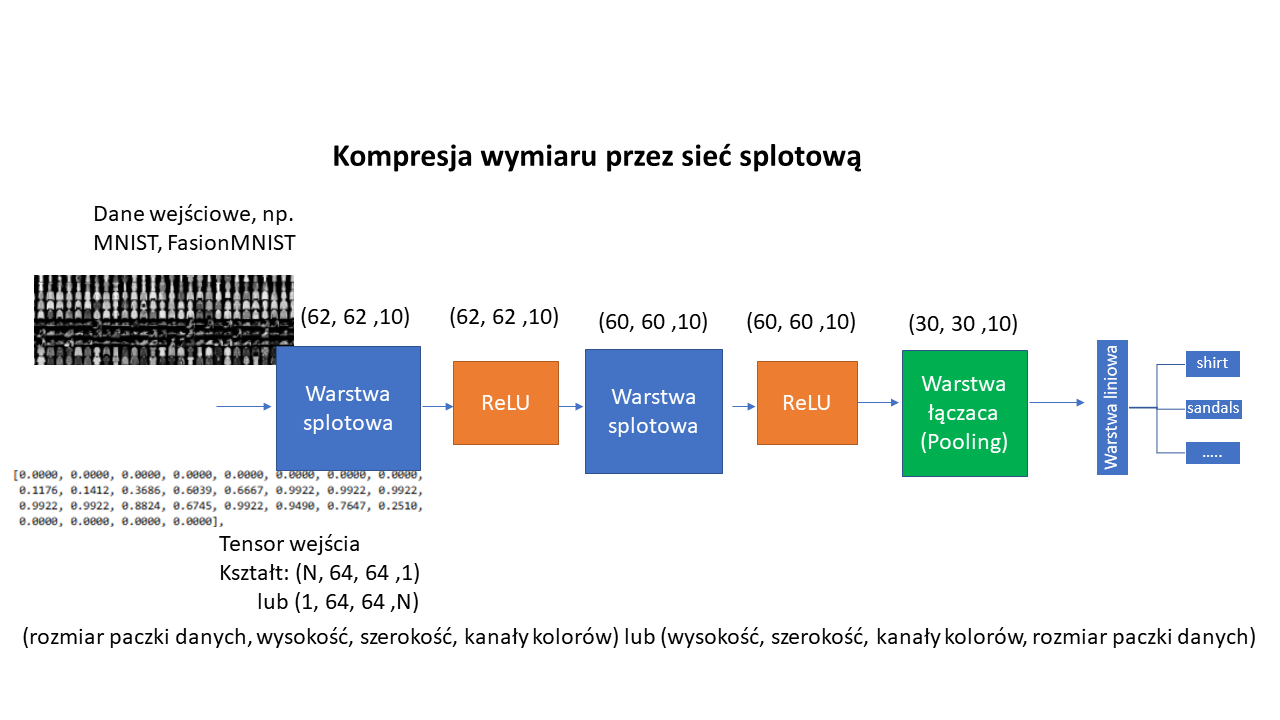

In [ ]:
from IPython.display import Image
Image('/content/Cw5Obraz4.png')


Oto pomysł użycia warstwy `nn.MaxPool2d()`: wzięcie maksymalnej wartości z części tensora i zignorowanie reszty.

W istocie, obniżenie wymiarowości tensora przy jednoczesnym zachowaniu (miejmy nadzieję) znacznej części informacji.

To samo dotyczy warstwy `nn.Conv2d()`.

Z tą różnicą, że zamiast po prostu wziąć maksimum, `nn.Conv2d()` wykonuje operację splotową na danych (zobacz to w akcji na [stronie internetowej CNN Explainer](https://poloclub.github.io/cnn-explainer/)).

> **Ćwiczenie:** Co Twoim zdaniem robi warstwa [`nn.AvgPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html)? Spróbuj utworzyć losowy tensor, tak jak zrobiliśmy powyżej i przepuść go. Sprawdź kształty wejściowe i wyjściowe, a także wartości wejściowe i wyjściowe.

> **Zajęcia dodatkowe:** Wyszukaj „najczęściej występujące sieci neuronowe splotowe”, jakie architektury znajdziesz? Czy któraś z nich jest zawarta w bibliotece [`torchvision.models`](https://pytorch.org/vision/stable/models.html)? Co Twoim zdaniem możesz z nimi zrobić?

### 7.3 Konfiguracja funkcji straty i optymalizatora dla `model_2`

Przeszliśmy przez warstwy w naszym pierwszym CNN wystarczająco.

Ale pamiętaj, jeśli coś nadal nie jest jasne, spróbuj zacząć od małego.

Wybierz pojedynczą warstwę modelu, przepuść przez nią trochę danych i zobacz, co się stanie.

Teraz nadszedł czas, aby przejść dalej i rozpocząć trening!

Skonfigurujmy funkcję straty i optymalizator.

Użyjemy funkcji jak poprzednio, `nn.CrossEntropyLoss()` jako funkcji straty (ponieważ pracujemy z danymi klasyfikacji wieloklasowej).

Oraz `torch.optim.SGD()` jako optymalizatora do optymalizacji `model_2.parameters()` ze współczynnikiem uczenia `0.1`.

In [ ]:
# Definicja straty i optymalizacji
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

### 7.4 Trening i testowanie modelu `model_2`

Strata i optymalizator gotowe!

Czas na uczenie i testowanie.

Użyjemy naszych funkcji `train_step()` i `test_step()`, które stworzyliśmy wcześniej.

Zmierzymy również czas, aby porównać go z innymi modelami.

In [ ]:
# Pomiar czasu
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Uczenie i testowanie modelu
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Strata uczenia (Train loss): 0.58036 | Dokładność uczenia: 78.97%
Strata uczenia (Test loss): 0.44439 | Test accuracy: 84.06%

Epoch: 1
---------
Strata uczenia (Train loss): 0.35555 | Dokładność uczenia: 87.31%
Strata uczenia (Test loss): 0.34937 | Test accuracy: 87.81%

Epoch: 2
---------
Strata uczenia (Train loss): 0.31890 | Dokładność uczenia: 88.53%
Strata uczenia (Test loss): 0.32809 | Test accuracy: 87.97%

Train time on cuda: 33.035 seconds


Wygląda na to, że warstwy splotowe i max pool pomogły trochę poprawić wydajność.

Oceńmy wyniki `model_2` za pomocą naszej funkcji `eval_model()`.

In [ ]:
# Wyniki modelu 2 (model_2)
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'nazwa_modelu': 'FashionMNISTModelV2',
 'strata_modelu': 0.32809314131736755,
 'accuracy_modelu': 87.96924920127796}

## 8. Porównanie wyników modeli i czasu szkolenia

Przetrenowaliśmy trzy różne modele.

1. `model_0` - nasz model bazowy z dwiema warstwami `nn.Linear()`.
2. `model_1` - taka sama konfiguracja jak nasz model bazowy, z wyjątkiem warstw `nn.ReLU()` pomiędzy warstwami `nn.Linear()`.
3. `model_2` - nasz pierwszy model CNN, który naśladuje architekturę TinyVGG na stronie CNN Explainer.

Jest to regularna praktyka w uczeniu maszynowym.

Budowanie wielu modeli i przeprowadzanie wielu eksperymentów szkoleniowych, aby zobaczyć, który z nich działa najlepiej.

Połączmy słowniki wyników naszych modeli w DataFrame i przekonajmy się.

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,nazwa_modelu,strata_modelu,accuracy_modelu
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.328093,87.969249


Dobrze

Dodamy czasy uczenia

In [ ]:
# Dodaj czasy treningu do porównania wyników
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,nazwa_modelu,strata_modelu,accuracy_modelu,training_time
0,FashionMNISTModelV0,0.476639,83.426518,24.159672
1,FashionMNISTModelV1,0.685001,75.019968,27.118653
2,FashionMNISTModelV2,0.328093,87.969249,33.035176


Wygląda na to, że nasz model CNN (`FashionMNISTModelV2`) działał najlepiej (najniższa strata, najwyższa dokładność), ale miał najdłuższy czas szkolenia.

Nasz model bazowy (`FashionMNISTModelV0`) wypadł lepiej niż `model_1` (`FashionMNISTModelV1`).

### Kompromis między wydajnością a szybkością

Coś, czego należy być świadomym w uczeniu maszynowym, to kompromis **wydajność-prędkość**.

Ogólnie rzecz biorąc, uzyskuje się lepszą wydajność z większego, bardziej złożonego modelu (tak jak zrobiliśmy to z `model_2`).

Jednak ten wzrost wydajności często wiąże się z poświęceniem szybkości uczenia i wnioskowania.

> **Uwaga:** Czasy uczenia będą bardzo zależne od używanego sprzętu.
>
> Ogólnie rzecz biorąc, im więcej rdzeni CPU posiadasz, tym szybciej Twoje modele będą trenowane na CPU. I podobnie w przypadku GPU.
>
> Nowszy sprzęt (pod względem wieku) często będzie również szybciej trenować modele ze względu na postęp technologiczny.

Co powiesz na wizualizację?

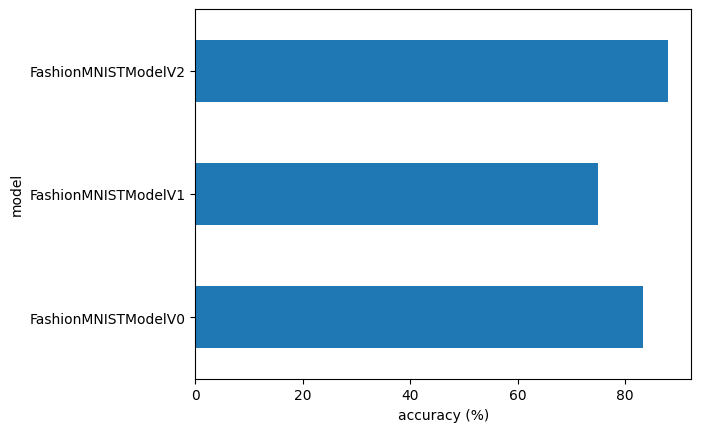

In [ ]:
# Wizualizacja wyników
compare_results.set_index("nazwa_modelu")["accuracy_modelu"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

## 9. Utwórz i oceń losowe prognozy z najlepszego modelu

Porównaliśmy nasze modele ze sobą, oceńmy  nasz najlepiej działający model, `model_2`.

Aby to zrobić, utwórzmy funkcję `make_predictions()`, w której możemy przekazać model i pewne dane, na podstawie których ma on przewidywać.

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # przygotowanie próbki
            sample = torch.unsqueeze(sample, dim=0).to(device) # Dodaj dodatkowy wymiar i wyślij próbkę do urządzenia

            # Przejście do przodu (model generuje surowy logit)
            pred_logit = model(sample)

            # Pobierz prawdopodobieństwo przewidywania (logit -> prawdopodobieństwo przewidywania)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) #  wykonaj softmax na wymiarze „logits”, a nie na wymiarze „batch” (w tym przypadku mamy rozmiar partii równy 1, więc można wykonać na dim=0)

            # Pobierz pred_prob z GPU w celu dalszych obliczeń
            pred_probs.append(pred_prob.cpu())

    # Ułóż pred_probs w stos, aby zamienić listę w tensor
    return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# Wyświetl kształt i etykietę pierwszej próbki testowej
print(f"Kształt próbki testowej: {test_samples[0].shape}\nEtykieta próbki testowej: {test_labels[0]} ({class_names[test_labels[0]]})")

Kształt próbki testowej: torch.Size([1, 28, 28])
Etykieta próbki testowej: 5 (Sandal)


In [ ]:
# Prognozowanie na próbkach testowych przy użyciu modelu 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# Podgląd prawdopodobieństw
pred_probs[:2]

tensor([[7.8053e-07, 1.0940e-09, 2.3743e-07, 9.5662e-09, 1.9181e-08, 9.9962e-01,
         8.5207e-07, 5.9972e-08, 5.0505e-06, 3.7712e-04],
        [4.3172e-01, 3.7621e-01, 2.2025e-02, 6.0826e-02, 4.9008e-02, 1.8183e-04,
         5.8240e-02, 1.0315e-04, 1.5286e-03, 1.5141e-04]])

Teraz możemy użyć naszej funkcji `make_predictions()` do przewidywania na `test_samples`.

In [ ]:
# Prognozowanie na próbkach testowych przy użyciu modelu 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# Wyświetl dwie pierwsze listy prawdopodobieństw przewidywań
pred_probs[:2]

tensor([[7.8053e-07, 1.0940e-09, 2.3743e-07, 9.5662e-09, 1.9181e-08, 9.9962e-01,
         8.5207e-07, 5.9972e-08, 5.0505e-06, 3.7712e-04],
        [4.3172e-01, 3.7621e-01, 2.2025e-02, 6.0826e-02, 4.9008e-02, 1.8183e-04,
         5.8240e-02, 1.0315e-04, 1.5286e-03, 1.5141e-04]])

Doskonale!

A teraz możemy przejść od prawdopodobieństwa predykcji do etykiet predykcji, biorąc `torch.argmax()` wyjścia funkcji aktywacji `torch.softmax()`.

In [ ]:
# Zamień prawdopodobieństwa predykcji na etykiety predykcji, biorąc argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 0, 7, 4, 3, 0, 4, 7, 1])

In [ ]:
# Czy nasze przewidywania mają taką samą formę jak nasze etykiety testowe?
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 0, 7, 4, 3, 0, 4, 7, 1]))

Teraz nasze przewidywane klasy są w tym samym formacie, co nasze etykiety testowe, możemy je porównać.

Ponieważ mamy do czynienia z danymi obrazu, pozostańmy wierni mottu eksploratora danych.

„Wizualizuj, wizualizuj, wizualizuj!”.

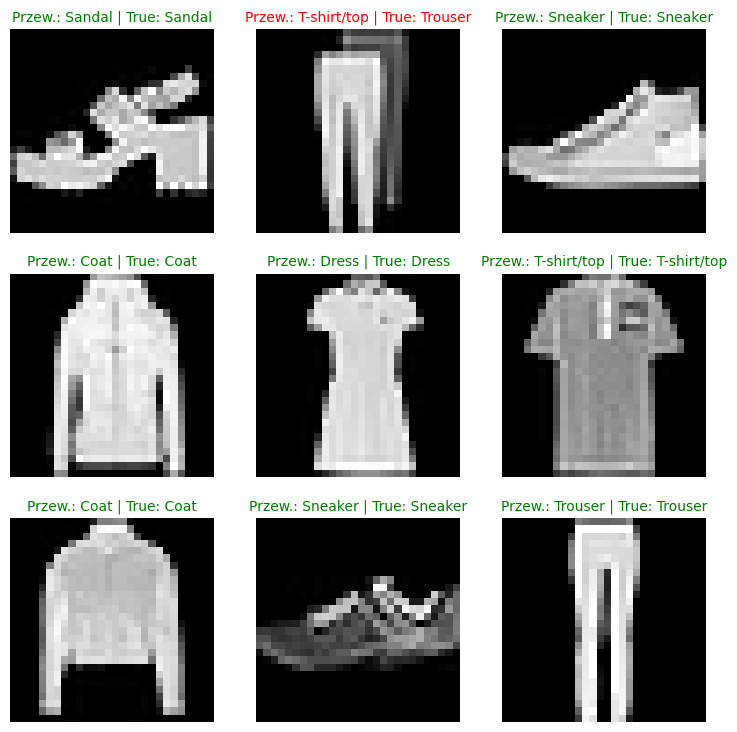

In [ ]:
# Wykres przewidywań
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Tworzenie podwykresu
  plt.subplot(nrows, ncols, i+1)

  # Narysuj obraz docelowy
  plt.imshow(sample.squeeze(), cmap="gray")

  # Wyznaczenie etykiety przewidywanej klasy (jako tekst, np. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Znalezienie rzeczywstej etykiety (jako tekst, np. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Tutuł wykresu
  title_text = f"Przew.: {pred_label} | True: {truth_label}"

  # Zbadanie zgodności i zmiana koloru
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # zielone, jeśli OK
  else:
      plt.title(title_text, fontsize=10, c="r") # czerwone, jeśli błąd
  plt.axis(False);

Całkiem dobrze.

## 10. Tworzenie macierzy pomyłek w celu dalszej oceny przewidywań

Istnieje wiele metod oceny jakosci klasyfikacj (patrz Wykład 3 i ćw. 3).

Jedną z najbardziej wizualnych jest [macierz pomyłek](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/).

Macierz pomyłek pokazuje, gdzie model klasyfikacji myli przewidywania z prawdziwymi etykietami.

Aby utworzyć macierz pomyłek, przejdziemy przez trzy kroki:
1. Utwórz przewidywania za pomocą naszego wytrenowanego modelu, `model_2` (macierz pomyłek porównuje przewidywania z prawdziwymi etykietami).
2. Utwórz macierz pomyłek za pomocą [`torchmetrics.ConfusionMatrix`](https://pytorch.org/ignite/generated/ignite.metrics.confusion_matrix.ConfusionMatrix.html).
3. Narysuj macierz pomyłek za pomocą [`mlxtend.plotting.plot_confusion_matrix()`](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/).

Zacznijmy od tworzenia prognoz za pomocą naszego wytrenowanego modelu.

In [ ]:
# Importujemy tqdm na potrzeby wizualizacji postępu obliczeń
from tqdm.auto import tqdm

# 1.  Prognozowanie przy użyciu wytrenowanego modelu
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # dane na docelowe urządzenie
    X, y = X.to(device), y.to(device)
    # Propadacja w przód
    y_logit = model_2(X)
    # Przekształć przewidywania z logitów -> prawdopodobieństwa przewidywań -> etykiety przewidywań
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # uwaga: robimy softmax na wymiarze „logits”, a nie na wymiarze „batch” (w tym przypadku mamy rozmiar partii 32, więc możemy wykonać na dim=1)
    # Umieść prognozy na CPU do oceny
    y_preds.append(y_pred.cpu())
# Łączenie listy prognoz w tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

Skoro już mamy przewidywania, przejdźmy do kroków 2 i 3:

2. Utwórz macierz pomyłek [`torchmetrics.ConfusionMatrix`](https://pytorch.org/ignite/generated/ignite.metrics.confusion_matrix.ConfusionMatrix.html).
3. Zrób wykres macierzy pomyłek [Confusion matrix](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/).

Najpierw musimy się upewnić, że mamy zainstalowane `torchmetrics` i `mlxtend` (te dwie biblioteki pomogą nam utworzyć i zwizualizować macierz pomyłek).

> **Uwaga:** Jeśli używasz Google Colab, domyślna zainstalowana wersja `mlxtend` to 0.23.4 (stan na marzec 2025), jednak dla parametrów funkcji `plot_confusion_matrix()`, której chcemy użyć, potrzebujemy wersji 0.19.0 lub nowszej.

In [ ]:
# Sprawdź, czy istnieje Torchmetrics, jeśli nie, zainstaluj go
try:
    import torchmetrics, mlxtend
    print(f"wersja mlxtend: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "wersja mlxtend powinna być 0.19.0 lub wyższa"
except:
    !pip install -q torchmetrics -U mlxtend # <- Uwaga: jeśli korzystasz z usługi Google Colab, może być konieczne ponowne uruchomienie środowiska wykonawczego
    import torchmetrics, mlxtend
    print(f"wersja mlxtend: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.7/931.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.8 MB/s eta 0:00:00
wersja mlxtend: 0.23.4


Aby narysować macierz pomyłek, musimy mieć pewność, że mamy wersję mlxtend 0.19.0 lub nowszą.

In [ ]:
# Importowanie wersji mlxtend
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 #powinna być 0.19.0 lub większa

0.23.4


Po zainstalowaniu `torchmetrics` i `mlxtend`, stwórzmy macierz pomyłek!

Najpierw utworzymy instancję `torchmetrics.ConfusionMatrix`, informując ją, z iloma klasami mamy do czynienia, ustawiając `num_classes=len(class_names)`.

Następnie utworzymy macierz pomyłek (w formacie tensora), przekazując naszej instancji przewidywania naszego modelu (`preds=y_pred_tensor`) i cele (`target=test_data.targets`).

Na koniec możemy wykreślić naszą macierz pomyłek za pomocą funkcji `plot_confusion_matrix()` z `mlxtend.plotting`.

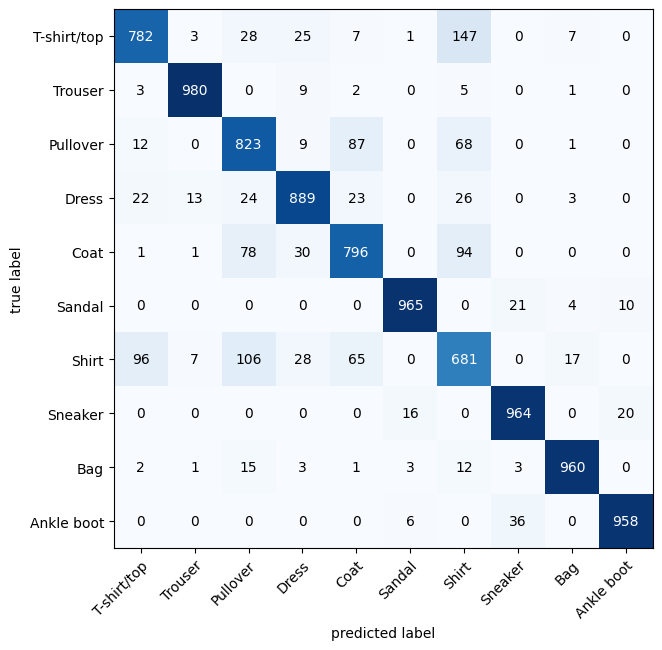

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Skonfiguruj macierz pomyłek i porównaj przewidywania z celami
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Wykres  macierzy pomyłek (confusion matrix)
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib działa z NumPy
    class_names=class_names, # zmień etykiety wierszy i kolumn na nazwy klas
    figsize=(10, 7)
);

Czy to nie wygląda dobrze?

Widzimy, że nasz model radzi sobie całkiem dobrze, ponieważ większość ciemnych kwadratów znajduje się po przekątnej od lewego górnego rogu do prawego dolnego rogu (a idealny model będzie miał tylko wartości w tych kwadratach i 0 wszędzie indziej).

Model jest najbardziej „zdezorientowany” w klasach, które są podobne, na przykład przewidując „Pullover” dla obrazów, które w rzeczywistości są oznaczone jako „Shirt”.

To samo dotyczy przewidywania „Shirt” dla klas, które w rzeczywistości są oznaczone jako „T-shirt/top”.

Tego rodzaju informacje są często bardziej pomocne niż pojedynczy wskaźnik dokładności, ponieważ informują *gdzie* model popełnia błędy.

Wskazuje również *dlaczego* model może się mylić.

Zrozumiałe jest, że model czasami przewiduje „Shirt” dla obrazów oznaczonych jako „T-shirt/top”.

Możemy użyć tego rodzaju informacji do dalszej inspekcji naszych modeli i danych, aby zobaczyć, jak można je ulepszyć.

> **Ćwiczenie:** Użyj wytrenowanego `modelu_2` do przewidywania na testowym zbiorze danych FashionMNIST. Następnie wykreśl kilka przewidywań, w których model był błędny, obok tego, jaka powinna być etykieta obrazu. Czy po wizualizacji tych przewidywań uważasz, że jest to bardziej błąd modelowania czy błąd danych? Chodzi o to, czy model mógłby poradzić sobie lepiej, czy też etykiety danych są zbyt blisko siebie (np. etykieta „Koszula” jest zbyt blisko etykiety „T-shirt/top”)?

### 11. Zapisywanie i wczytywanie najlepiej działającego modelu

Zakończmy ćwiczenia, zapisując i ładując nasz najlepiej działający model.

Przypomnijmy (Ćw. 2), że możemy zapisać i załadować model PyTorch używając kombinacji:
* `torch.save` - funkcja zapisująca cały model PyTorch lub `state_dict()` modelu.
* `torch.load` - funkcja do załadowania zapisanego obiektu PyTorch.
* `torch.nn.Module.load_state_dict()` - funkcja ładująca zapisany `state_dict()` do istniejącej instancji modelu.

Więcej informacji na temat tych trzech funkcji można znaleźć w dokumentacji [PyTorch saving and loading models documentation](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

Na razie zapiszmy `state_dict()` naszego `model_2`, a następnie załadujmy go z powrotem i oceńmy, aby upewnić się, że zapis i ładowanie przebiegły poprawnie.
                



In [ ]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("modele")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: modele/03_pytorch_computer_vision_model_2.pth


Teraz mamy zapisany model `state_dict()`, który możemy załadować z powrotem używając kombinacji `load_state_dict()` i `torch.load()`.

Ponieważ używamy `load_state_dict()`, będziemy musieli utworzyć nową instancję `FashionMNISTModelV2()` z tymi samymi parametrami wejściowymi co nasz zapisany model `state_dict()`.

In [ ]:
# Utwórz nową instancję FashionMNISTModelV2 (ta sama klasa co nasz zapisany state_dict())
# Uwaga: ładowanie modelu spowoduje błąd, jeśli kształty tutaj nie są takie same jak w zapisanej wersji.
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                    hidden_units=10, # zmień na 128 and i zobacz, co się stanie
                                    output_shape=10)

# Wczytanie zapisanego state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Wysłanie modelu na GPU
loaded_model_2 = loaded_model_2.to(device)

Teraz, gdy mamy załadowany model, możemy ocenić go za pomocą `eval_model()`, aby upewnić się, że jego parametry działają podobnie do `model_2` przed zapisaniem.

In [ ]:
# Ocena załadowanego modelu
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'nazwa_modelu': 'FashionMNISTModelV2',
 'strata_modelu': 0.32809314131736755,
 'accuracy_modelu': 87.96924920127796}

Czy wyniki wyglądają tak samo jak  `model_2_results`?

In [ ]:
model_2_results

{'nazwa_modelu': 'FashionMNISTModelV2',
 'strata_modelu': 0.32809314131736755,
 'accuracy_modelu': 87.96924920127796}

Możemy dowiedzieć się, czy dwa tensory są blisko siebie, używając `torch.isclose()` i przekazując poziom tolerancji bliskości za pomocą parametrów `atol` (tolerancja bezwzględna) i `rtol` (tolerancja względna).

Jeśli wyniki naszego modelu są bliskie, wynik `torch.isclose()` powinien być prawdziwy.

In [ ]:
# Sprawdź, czy wyniki są zbliżone do siebie (jeśli są bardzo odległe, może wystąpić błąd)
torch.isclose(torch.tensor(model_2_results["strata_modelu"]),
              torch.tensor(loaded_model_2_results["strata_modelu"]),
              atol=1e-08, # bezwzględna tolerancja
              rtol=0.0001) # względna tolerancja

tensor(True)

## Zadanie
* **Polecam:** [Kurs MIT Wstęp do wizji komputerowej](https://www.youtube.com/watch?v=2xqkSUhmmXU). To da ci świetną intuicję na temat sieci neuronowych splotowych.
* Poświęć 10 minut na klikanie w różne opcje [biblioteki wizji PyTorch](https://pytorch.org/vision/stable/index.html) i sprawdź jakie  moduły są dostępne.
* Wyszukaj „najczęściej występujące sieci splotowe”. Jakie architektury znajdziesz? Czy któraś z nich jest zawarta w bibliotece [`torchvision.models`](https://pytorch.org/vision/stable/models.html)?
* Aby uzyskać dużą liczbę wstępnie wytrenowanych modeli wizji komputerowej PyTorch, a także wiele różnych rozszerzeń funkcji wizji komputerowej PyTorch, sprawdź [bibliotekę modeli obrazów PyTorch `timm`](https://github.com/rwightman/pytorch-image-models/) (Torch Image Models) autorstwa Rossa Wightmana.